In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from IPython.display import clear_output
from matplotlib import cm


In [31]:
# Load all data
folder = Path(r'C:\Users\Dave Amin\Documents\docs-Sync\Career\2025-10 IC AI course\Modules\Capstone2\initial_data')
folder2 = Path(r'function_1')

def load_data():
    file_path_inputs =  folder / folder2 / rf"initial_inputs.npy"
    file_path_outputs = folder / folder2 / rf"initial_outputs.npy"
    X = np.load(file_path_inputs)
    Y = np.load(file_path_outputs)
    print('Initial data :','X.shape', X.shape, 'Y.shape', Y.shape)
    
    X_new_point = np.array([0.693878, 0.877551], dtype=np.float64)
    Y_new_point = np.array([1.3147995487661745e-46], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 1 :','X.shape', X.shape, 'Y.shape', Y.shape)

    # week 2 new values go here !!!!
  
    return X,Y

X,Y = load_data()

Initial data : X.shape (10, 2) Y.shape (10,)
Added week 1 : X.shape (11, 2) Y.shape (11,)


In [4]:
# print('X.shape', X.shape)
# print('X col1 min',np.min(X[:, 0]), 'max',np.max(X[:, 0]))
# print('X col2 min',np.min(X[:, 1]), 'max',np.max(X[:, 1]))
# print('Y.shape', Y.shape)
# print("Min Y =",min(Y),"Max Y =",max(Y))

In [22]:
print("X",X)
print("Y",Y)

X [[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.693878   0.877551  ]]
Y [ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048  1.31479955e-046]


In [6]:
def heat_scatter(X,Y):
    plt.figure(figsize=(10, 7))
    
    # We use SymLogNorm because your data has negatives and extremely small positives
    norm = colors.SymLogNorm(linthresh=1e-20, linscale=1, vmin=Y.min(), vmax=Y.max())
    
    scatter = plt.scatter(X[:, 0], X[:, 1], c=Y, s=200, edgecolors='black', 
                          cmap='RdYlBu', norm=norm)
    
    # Add labels for each point's order (1 to 10)
    for i, txt in enumerate(range(1, len(Y) + 1)):
        plt.annotate(txt, (X[i, 0]+0.02, X[i, 1]+0.02))
    plt.colorbar(scatter, label='Y value (Symmetric Log Scale)')
    plt.xlabel('Input Feature 1 ($x_1$)')
    plt.ylabel('Input Feature 2 ($x_2$)')
    plt.title('Contest Data: Sample Locations and Observations')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

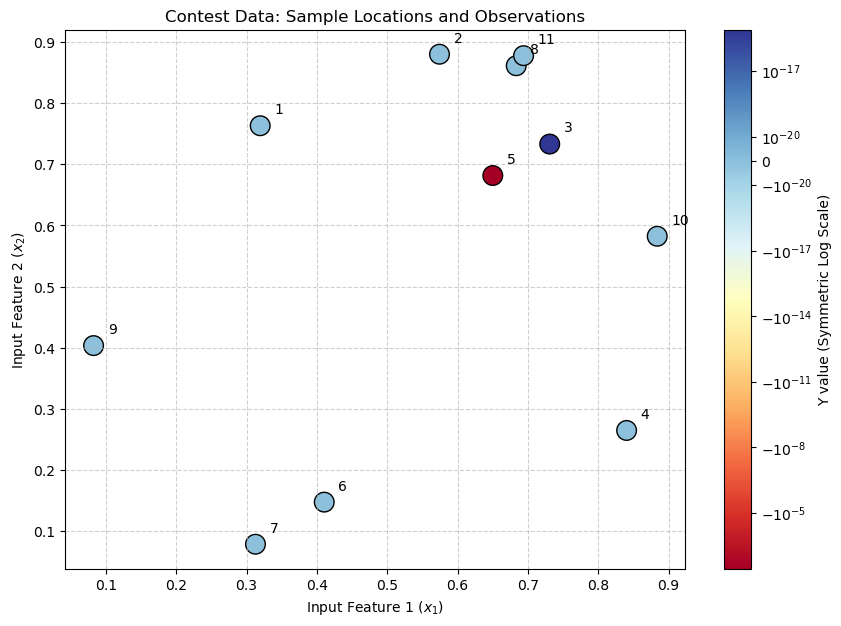

In [7]:
heat_scatter(X,Y)

In [7]:
# def plot3Dprediction(X,Y,model):
#     import numpy as np
#     import matplotlib.pyplot as plt
#     from matplotlib import cm
    
#     # 1. Determine the bounds of your loaded data for the grid
#     # 2. Create a dense grid for predictions
#     # We use 50x50 points to create a smooth surface
#     x1_linspace = np.linspace(0, 1, 50)
#     x2_linspace = np.linspace(0, 1, 50)
#     X1_grid, X2_grid = np.meshgrid(x1_linspace, x2_linspace)
    
#     # Flatten the grid to feed into the model
#     x_test = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])
    
#     # 3. Predict using your fitted model
#     y_pred, std = model.predict(x_test, return_std=True)
    
#     # Reshape predictions back into the grid shape for plotting
#     Z_mean = y_pred.reshape(X1_grid.shape)
#     Z_std = std.reshape(X1_grid.shape)
    
#     # 4. Create the Visualization
#     fig = plt.figure(figsize=(16, 6))
    
#     # --- Subplot 1: 3D Surface of Predicted Mean ---
#     ax1 = fig.add_subplot(121, projection='3d')
#     surf = ax1.plot_surface(X1_grid, X2_grid, Z_mean, cmap='viridis', alpha=0.8, edgecolor='none')
#     ax1.scatter(X[:, 0], X[:, 1], Y, color='red', marker='x', s=50, label='Actual Data')
#     ax1.set_title('GP Predicted Mean Surface')
#     ax1.set_zlabel('Output Y')
#     fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)
    
#     # --- Subplot 2: Heatmap of Uncertainty (Std Dev) ---
#     ax2 = fig.add_subplot(122)
#     contour = ax2.contourf(X1_grid, X2_grid, Z_std, levels=20, cmap='YlOrRd')
#     # contour = ax2.contourf(X1_grid, X2_grid, Z_mean, levels=20, cmap='YlOrRd')
#     ax2.scatter(X[:, 0], X[:, 1], c='black', marker='+', alpha=0.5)
#     ax2.set_title('Model Uncertainty (Std Dev)')
#     ax2.set_xlabel('Input Feature 1')
#     ax2.set_ylabel('Input Feature 2')
#     fig.colorbar(contour, ax=ax2, label='Standard Deviation')
    
#     plt.tight_layout()
#     plt.show()

In [9]:
def plot3Dprediction2(X,Y, y_pred, std, X1_grid, X2_grid):
    # Reshape predictions back into the grid shape for plotting
    Z_mean = y_pred.reshape(X1_grid.shape)
    Z_std = std.reshape(X1_grid.shape)
    
    # 4. Create the Visualization
    fig = plt.figure(figsize=(16, 6))
    
    # --- Subplot 1: 3D Surface of Predicted Mean ---
    ax1 = fig.add_subplot(121, projection='3d')
    surf = ax1.plot_surface(X1_grid, X2_grid, Z_mean, cmap='viridis', alpha=0.8, edgecolor='none')
    ax1.scatter(X[:, 0], X[:, 1], Y, color='red', marker='x', s=50, label='Actual Data')
    ax1.set_title('GP Predicted Mean Surface')
    ax1.set_zlabel('Output Y')
    fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)
    
    # --- Subplot 2: Heatmap of Uncertainty (Std Dev) ---
    ax2 = fig.add_subplot(122)
    contour = ax2.contourf(X1_grid, X2_grid, Z_std, levels=20, cmap='YlOrRd')
    # contour = ax2.contourf(X1_grid, X2_grid, Z_mean, levels=20, cmap='YlOrRd')
    ax2.scatter(X[:, 0], X[:, 1], c='black', marker='+', alpha=0.5)
    ax2.set_title('Model Uncertainty (Std Dev)')
    ax2.set_xlabel('Input Feature 1')
    ax2.set_ylabel('Input Feature 2')
    fig.colorbar(contour, ax=ax2, label='Standard Deviation')
    
    plt.tight_layout()
    plt.show()

## Matern Kernel

In [23]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
X,Y = load_data()
# 1. Define the Kernel
# Matern is the gold standard for black-box optimization.
# nu=2.5 provides a good balance between smoothness and flexibility.
Matern_kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=[0.1, 0.1], 
                                     length_scale_bounds=(1e-2, 1.5),
                                             nu=1.5   # Less smooth, better for sharp radiation spikes
                                     ) + WhiteKernel(noise_level=1e-10, 
                                    noise_level_bounds=(1e-10, 1e-5))
# 2. Setup the Regressor
model = GaussianProcessRegressor(
    kernel=Matern_kernel,
    alpha=0,               # Let WhiteKernel handle the noise instead
    normalize_y=True,        # CRITICAL: This scales those tiny e-124 values so the GP can see them
    n_restarts_optimizer=20)   # Gives the optimizer 15 tries to find the best fit
# 3. Fit the model
model.fit(X, Y)
print(f"Optimized Kernel: {model.kernel_}")

Initial data : X.shape (10, 2) Y.shape (10,)
Added week 1 : X.shape (11, 2) Y.shape (11,)
Optimized Kernel: 1.03**2 * Matern(length_scale=[1.5, 0.03], nu=1.5) + WhiteKernel(noise_level=4.9e-09)


C:\Anaconda\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 1.5. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## acquisition_function = Expected Improvement

In [30]:
import numpy as np
from scipy.stats import norm

def expected_improvement(x, model, best_y, xi=0.01):
    """
    Computes the Expected Improvement (EI) at point x.
    
    Args:
        x: The input point to evaluate (1D numpy array).
        model: The trained GaussianProcessRegressor.
        best_y: The best observed value so far (scalar).
        xi: Exploration parameter (default 0.01). 
            Higher xi = more exploration (finding weak sources).
            Lower xi = more exploitation (refining strong sources).
            
    Returns:
        ei: The scalar Expected Improvement value.
    """
    # 1. Get the mean (mu) and uncertainty (sigma) from the model
    mu, sigma = model.predict(x.reshape(1, -1), return_std=True)
    
    # 2. Handle cases with zero uncertainty (sampled points) to avoid divide-by-zero
    if sigma == 0:
        return 0.0
    
    # 3. Calculate the Z-score (standardized improvement)
    # We subtract xi to force the model to look for improvements *at least* size xi
    imp = mu - best_y - xi
    Z = imp / sigma
    
    # 4. The EI Formula
    # Part A: Probability of improvement (cdf) * Amount of improvement
    # Part B: Accounts for uncertainty (pdf)
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    
    return ei[0]

from scipy.optimize import minimize

# 1. Identify the best value found so far
current_best_y = np.max(Y) 

# 2. Define the objective for the optimizer (Negative EI)
def min_obj(x):
    return -expected_improvement(x, model, current_best_y, xi=0.01)

# 3. Run the optimizer
# Random start point for the local search
x_start = np.random.uniform(0, 1, size=X.shape[1]) 

res = minimize(min_obj, x0=x_start, bounds=[(0, 1)] * X.shape[1], method='L-BFGS-B')

# print(f"Next best point to interrogate: {res.x}")
formatted_submission_string = "-".join(f"{val:.6f}" for val in res.x)
print(f"Submit this: {formatted_submission_string}")

# Find the Predicted Y
next_point = res.x.reshape(1, -1)
predicted_mean, predicted_std = model.predict(next_point, return_std=True)
print(f"Predicted Y is {predicted_mean[0]:.4e} with Uncertainty (Std): {predicted_std[0]:.4e}")

Submit this: 0.191011-0.540393
Predicted Y is -2.2408e-04 with Uncertainty (Std): 1.0229e-03


## Submission results:
1.
Submit this: 0.409284-0.912102        Gemini confirms this is a valid suggestion
2.
Submit this: 0.851084-0.481114
3.
Submit this: 0.191011-0.540393
Predicted Y is -2.2408e-04 with Uncertainty (Std): 1.0229e-03

## acquisition_function = UCB   - IGNORE THIS

In [21]:
# ucbBeta = 1.96

for ucbBeta in np.linspace(2, 0, 8):
    
    # create empty grid to feed in to the model
    x1_linspace = np.linspace(0, 1, 50)
    x2_linspace = np.linspace(0, 1, 50)
    X1_grid, X2_grid = np.meshgrid(x1_linspace, x2_linspace)
    x_grid = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])
    
    #Clear the outputs to keep the interface clean
    # clear_output(wait = True)
    post_mean, post_std = model.predict(x_grid, return_std=True)
    # print("Prediction done")

    # plot3Dprediction2(X,Y, post_mean, post_std, X1_grid, X2_grid)
    # DISPLAY OF X AND Y
    # X_format =  ['%.2f' % query[0] + ', %.2f' % query[1] for query in X]  # Format for 2D points
    # Y_format = ['%.4e' % obs for obs in Y] #Four sig figs
    # data = [(query, obs) for query, obs in zip(X_format, Y_format)]
    # print('Data so far (sorted by descending observations): ')
    # print('\n'.join('{}: (x, f(x)) = {}'.format(*k) for k in enumerate(data, start = 1))) #Display data
    
    # Acquisition function (UCB)
    acquisition_function = post_mean + ucbBeta * post_std
    
    best_index = np.argmax(acquisition_function)
    x_next = x_grid[best_index]  # This will be a 2D point
    y_predicted = post_mean[best_index]
    
    print(f"With ucbBeta={ucbBeta:.3f}, the GP predicts [{x_next[0]:.6f}, {x_next[1]:.6f}] will be {y_predicted:.6f}")


With ucbBeta=2.000, the GP predicts [0.734694, 0.510204] will be -0.000258
With ucbBeta=1.714, the GP predicts [0.755102, 0.510204] will be -0.000258
With ucbBeta=1.429, the GP predicts [0.000000, 0.530612] will be -0.000191
With ucbBeta=1.143, the GP predicts [0.877551, 0.530612] will be -0.000191
With ucbBeta=0.857, the GP predicts [0.877551, 0.530612] will be -0.000191
With ucbBeta=0.571, the GP predicts [0.000000, 0.551020] will be -0.000074
With ucbBeta=0.286, the GP predicts [0.020408, 0.122449] will be -0.000015
With ucbBeta=0.000, the GP predicts [1.000000, 0.755102] will be 0.000114


results 1
With ucbBeta=2.000, the GP predicts [0.734694, 0.510204] will be -0.000258
With ucbBeta=1.714, the GP predicts [0.755102, 0.510204] will be -0.000258
With ucbBeta=1.429, the GP predicts [0.000000, 0.530612] will be -0.000191
With ucbBeta=1.143, the GP predicts [0.877551, 0.530612] will be -0.000191
With ucbBeta=0.857, the GP predicts [0.877551, 0.530612] will be -0.000191
With ucbBeta=0.571, the GP predicts [0.000000, 0.551020] will be -0.000074
With ucbBeta=0.286, the GP predicts [0.020408, 0.122449] will be -0.000015
With ucbBeta=0.000, the GP predicts [1.000000, 0.755102] will be 0.000114


## RBF Kernel - IGNORE

In [186]:
# # ########  IGNORE THIS 
# X,Y = load_data()
# # define the kernel, initialise the GP model, train
# from sklearn.gaussian_process import GaussianProcessRegressor
# from sklearn.gaussian_process.kernels import RBF
# rbf_lengthscale = 0.1
# noise_assumption = 1e-8
# # kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
# RBFkernel = RBF(length_scale=0.1, length_scale_bounds=(1e-2, 1e5))
#                      # length_scale_bounds=(1e-2, 1e3)  = model searches for good value
# model = GaussianProcessRegressor(kernel = RBFkernel, alpha=noise_assumption, n_restarts_optimizer=25)
#                      # n_restarts_optimizer runs the optimization 10 times
# model.fit(X, Y)
# print(f"Optimized Kernel: {model.kernel_}")

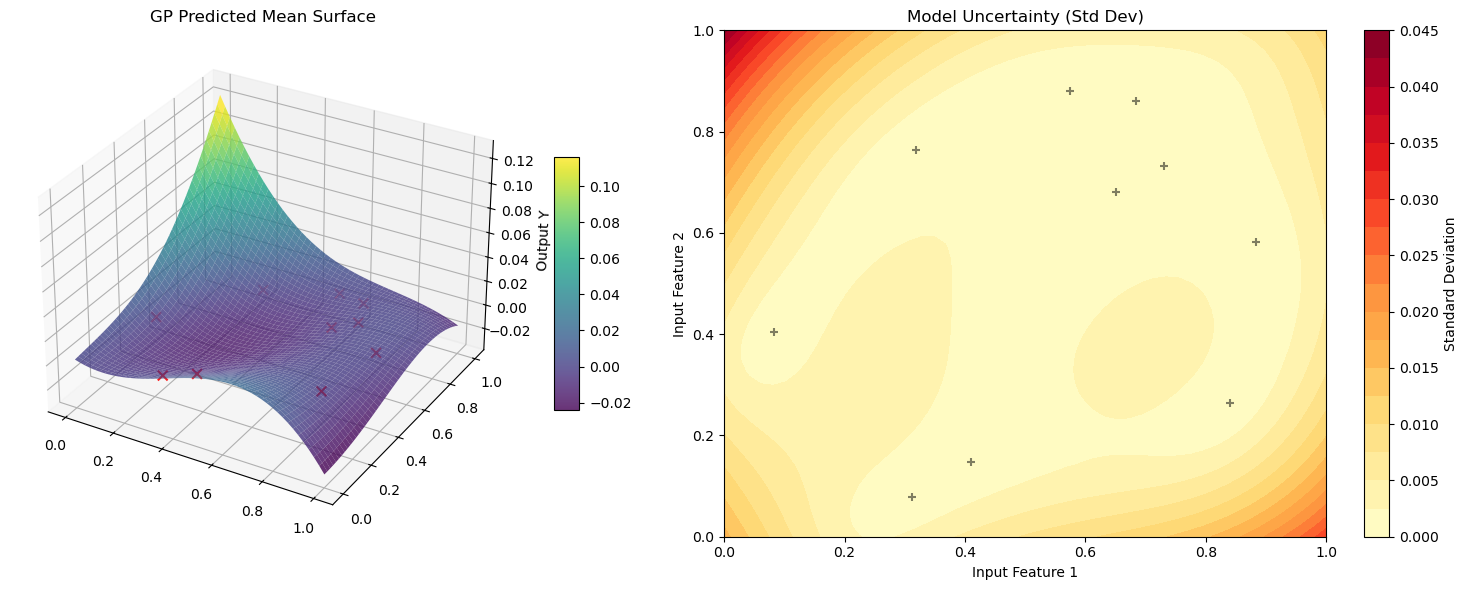

TypeError: only length-1 arrays can be converted to Python scalars

In [61]:
# AcquisitionFunctionBeta = 1.96
# max_obs = -1

# # create empty grid to feed in to the model
# x1_linspace = np.linspace(0, 1, 50)
# x2_linspace = np.linspace(0, 1, 50)
# X1_grid, X2_grid = np.meshgrid(x1_linspace, x2_linspace)
# # Flatten the grid to feed into the model
# x_grid = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])

# #Number of queries in the optimisation loop
# num_queries = 1

# for i in range(0, num_queries):
#     clear_output(wait = True)
#     # model = GaussianProcessRegressor(kernel = kernel, alpha=noise_assumption)
#     # model = GaussianProcessRegressor(kernel=RBFkernel,alpha=0, normalize_y=True, n_restarts_optimizer=20)
#     #Fit the model
#     # model.fit(X,Y)
#     #Calculate the mean and standard deviation and make them one-dimensional for plotting
#     post_mean, post_std = model.predict(x_grid, return_std=True)
#     # post_mean, post_std = post_mean.squeeze(), post_std.squeeze()
    
#     #Initialise plots
#     plot3Dprediction2(X,Y,model)
    
#     # DISPLAY OF X AND Y
#     #Select a display format for X and Y
#     X_format = ['%.2f' % query for query in X] #Two sig figs
#     Y_format = ['%.4f' % obs for obs in Y] #Four sig figs
#     data = [(query, obs) for query, obs in zip(X_format, Y_format)]
#     print('Data so far (sorted by descending observations): ')
#     print('\n'.join('{}: (x, f(x)) = {}'.format(*k) for k in enumerate(data, start = 1))) #Display data
    
#     #Initialise x
#     x = -1
#     # _ = input('Input anything to see the next chosen point') #You are using this to allow the user to change plots
    
#     acquisition_function = post_mean + AcquisitionFunctionBeta * post_std
    
#     grid = x_grid.squeeze()
#     x = grid[np.argmax(acquisition_function)]         #  use the acquisition function
#     print("argmax from acquisition_function =",x)

#     best_index = np.argmax(acquisition_function)
#     x_next = grid[best_index]
#     y_predicted = post_mean[best_index]   
#     print(f"The GP predicts the value at {x_next:.4f} will be {y_predicted:.4f}")

#     #Append data, calculate function and sort lists according to observation values
#     X.append(x)
#     y = y_predicted
#     Y.append(y)
#     X = [x for _, x in sorted(zip(Y, X), reverse = True)]
#     Y.sort(reverse = True)
#     max_obs = max(max_obs, y)


## Misc

In [103]:
num = 1

for i in range(0, num):
    print("count")

count
